In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
! pip install ultralytics==8.0.188 pillow==10.2.0 opencv-python==4.8.0.76 tensorflow==2.12.0 numpy==1.23.1

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [1]:
from ultralytics import YOLO

In [2]:
# !pip install tensorflow==2.16.0

In [3]:
#!pip install tensorflow==2.12.0

In [4]:
import tensorflow as tf
tf.__version__

'2.12.0'

In [5]:
import numpy as np
from PIL import Image
import pandas as pd
import cv2, os, math, pickle
import uuid
import tensorflow as tf
from keras.models import load_model
import base64
# from . import Species_Classification, sardine, mackerel, prawns, size

yolo = YOLO(r'/content/drive/MyDrive/Sowmya /models/segmentation/kartik/fish.pt')
cut = YOLO(r'/content/drive/MyDrive/Sowmya /models/cut-seg.pt')
scale_model = YOLO(r'/content/drive/MyDrive/Sowmya /models/Sardine/v4/scale_detection_model.pt')
model = load_model(r"/content/drive/MyDrive/Sowmya /models/Sardine/sardine_june.h5")
model_path = '/content/drive/MyDrive/Sowmya /models/Sardine/v4/Logistic Regression.pkl'

with open(model_path, 'rb') as f:
    size_model = pickle.load(f)

print('All models loaded successfully')

target_size = (224, 224)
threshold = 0.5 #0.478963

def process_image(image):
    resized_image = cv2.resize(image,target_size)
    processed_image = tf.keras.applications.densenet.preprocess_input(resized_image)
    processed_image = tf.expand_dims(processed_image, axis=0)
    return processed_image

def predict_sardine(image):
    image = process_image(image)
    pred = model.predict(image, verbose=0)
    print(pred[0][0])
    label = 'Good' if pred[0][0] >= threshold else 'Bad'
    return label

def save_image(image_input, folder_path=r'temp/'):
    os.makedirs(folder_path, exist_ok=True)
    unique_filename = str(uuid.uuid4()) + ".jpeg"
    image_path = os.path.join(folder_path, unique_filename)
    image = Image.fromarray(image_input)
    image.save(image_path, "JPEG")
    return image_path

def get_fish_height(box):
  x1, y1, x2, y2 = map(float, box)
  h = abs(y2 - y1)
  w = abs(x2 - x1)
  if h<w: (h, w) = (w, h)
  d = math.sqrt(w**2 + h**2)
  return h, w, d


def circumference_area(img):
    # Load the segmented fish image
    # image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Threshold the image to create a binary mask
    _, binary_mask = cv2.threshold(image, 1, 255, cv2.THRESH_BINARY)

    # Find contours in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Ensure at least one contour was found
    if len(contours) > 0:
        # Get the largest contour (presumably the fish)
        largest_contour = max(contours, key=cv2.contourArea)

        # Calculate the circumference of the contour
        circumference = cv2.arcLength(largest_contour, closed=True)

        # Calculate the area enclosed by the contour
        area = cv2.contourArea(largest_contour)

        return circumference, area

# def get_segmented_img(pred, index=0):
#     img_shape = pred.orig_shape
#     img = pred.orig_img.copy()
#     height, width = img_shape[0], img_shape[1]
#     masks = pred.masks.xy
#     seg_img_list = []
#     for i in range(len(masks)):
#         if i != index: continue
#         mask = masks[i]
#         mask_points = mask.astype(int)
#         binary_mask = np.zeros((height, width), dtype=np.uint8)
#         cv2.fillPoly(binary_mask, [mask_points], 255)
#         masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
#         x, y, w, h = cv2.boundingRect(mask_points)
#         segment_image = np.zeros((height, width, 3), dtype=np.uint8)
#         segment_image[y:y+h, x:x+w] = masked_img[y:y+h, x:x+w]
#         segment_image = segment_image[y:y+h, x:x+w]
#         white_background = False
#         if white_background:
#             black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
#             segment_image[black_mask] = [255, 255, 255]
#         seg_img_list.append(segment_image)
#     return seg_img_list


# def get_object_height(img_path, model, conf=0.5, iou=0.7, seg=False):
#     seg_img_list = None
#     results = model(img_path, conf=conf, iou=iou, verbose=False)
#     if len(results[0].boxes.cls) != 0:
#         index = 0
#         hp = int(results[0].boxes.xywh[index][3])
#         wp = int(results[0].boxes.xywh[index][2])
#         dp = int(math.hypot(hp, wp))
#         if hp<wp: (hp, wp) = (wp, hp)
#         obj_present = True
#         if seg: seg_img_list = get_segmented_img(results[0], index)
#     else:
#         hp, wp, dp = (0, 0, 0)
#         obj_present = False
#     return hp, wp, dp, obj_present, seg_img_list


def fish_measures_v2(sh, sw, sd, box):
    # Predict with the scale model
    scale_hp, scale_wp, scale_dp, scale = sh, sw, sd, True
    # Predict with the fish model
    fish_hp, fish_wp, fish_dp, fish, fish_img_list = *get_fish_height(box), True, None

    try:
        scale_hcm = 13
        one_pixel_value = scale_hcm / scale_hp
        fish_hcm = int(fish_hp * one_pixel_value)
        fish_wcm = int(fish_wp * one_pixel_value)
        fish_dcm = int(fish_dp * one_pixel_value)
        scale_dcm = int(scale_dp * one_pixel_value)
        scale_wcm = int(scale_wp * one_pixel_value)
    except:
        (fish_hcm, fish_wcm, fish_dcm,
         scale_dcm, scale_wcm, one_pixel_value) = (0, 0, 0, 0, 0, 0)

    return (fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm,
            fish, scale, fish_img_list, one_pixel_value)


def single_img_data_v2(img_path, segment, sh, sw, sd, box):
    filename = os.path.basename(img_path)
    (fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm, fish, scale,
     fish_img_list, one_pixel_value) = fish_measures_v2(sh, sw, sd, box)
    data = []
    # print('----------------------', segment.shape)
    circumference, area = circumference_area(img = segment)
    if one_pixel_value != 0:
      circumference = int(circumference * one_pixel_value)
      area = int(area * one_pixel_value * one_pixel_value)
    data.append((filename, fish_hcm, fish_wcm, fish_dcm,
                scale_dcm, scale_wcm, one_pixel_value,
                scale, fish, circumference, area))
    return data

def pred_single_img(test, model):
    probabilities = []
    for index, row in test.iterrows():
        if row['Scale']==False:
            print(f'Scale not detected @ {index}')
            break # go to softness model
        if row['Fish']==False:
            print(f'Fish not detected @ {index}')
            break
        Height = row['FishHeight']
        Width = row['FishWidth']
        diagonal = row['FishDiagonal']
        Circumference = row['Circumference']
        Area = row['Area']
        X_test = [[Height, Width, diagonal, Circumference, Area]]
        # pred = model.predict(X_test)
        # Get probability estimates for the predicted labels
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)
            # print(f"Probability :", y_proba)
        probabilities.append(y_proba)
    return probabilities

def get_object_height_v2(img_path, model, conf=0.5, iou=0.7, seg=False):
    seg_img_list = None
    results = model(img_path, conf=conf, iou=iou, verbose=False)
    if len(results[0].boxes.cls) != 0:
        index = 0
        hp = int(results[0].boxes.xywh[index][3])
        wp = int(results[0].boxes.xywh[index][2])
        dp = int(math.hypot(hp, wp))
        if hp<wp: (hp, wp) = (wp, hp)
        obj_present = True
    else:
        hp, wp, dp = (0, 0, 0)
        obj_present = False
    return hp, wp, dp, obj_present


def size_prediction(img_array,segment,box):
    try:
        print('triggered!!!!!!!!')
        # print(img_array.shape)
        img_path = save_image(img_array)
        sh, sw, sd, scale = get_object_height_v2(img_path, scale_model)
        data = single_img_data_v2(img_path, segment, sh, sw, sd, box)
        df = pd.DataFrame(data, columns=['Filename', 'FishHeight', 'FishWidth',
                                        'FishDiagonal', 'ScaleDiagonal', 'ScaleWidth',
                                        'OnePixelValue', 'Scale', 'Fish',
                                        'Circumference', 'Area'])
        display(df)
        probabilities = pred_single_img(df, size_model)
        threshold = 0.8
        if os.path.exists(img_path):
            try:
                os.remove(img_path)
            except Exception as e:
                print(e)
        # Adjust predictions based on the threshold
        predictions = np.ones(len(probabilities))
        for i in range(len(probabilities)):
            print('********lr probability :', probabilities[i][0][0], '**********')
            if probabilities[i][0][0] >= threshold:
                predictions[i] = 0
        label_map = {0: 'Bad', 1: 'Good'}
        for pred in predictions :
            label = label_map[int(pred)]

        if label == 'Good':
            print(f'size->{label}')
            return 'Good', None
        else:
            print(f'size->{label}')
            return 'Bad', 'Size'
    except Exception as e:
        print(e)
        return 'Good', None


def extract_single_image_segment2(img, mask_segment, shape):
    print("Extracting image segments for individual Fish/Prawn. -->V2")
    height, width = shape[0], shape[1]
    segment = np.array(mask_segment, dtype=np.int32)
    segment = segment.reshape((-1, 2))
    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(mask, [segment], 255)
    masked_img = cv2.bitwise_and(img, img, mask=mask)
    x, y, w, h = cv2.boundingRect(segment)
    segment_image = np.zeros((h, w, 3), dtype=np.uint8)
    segment_image[0:h, 0:w] = masked_img[y:y+h, x:x+w]
    black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
    segment_image[black_mask] = [255, 255, 255]
    return segment_image

def extract_single_image_segment(img, mask_segment, shape, background='black'):
    height, width = shape[0], shape[1]
    segment = np.array(mask_segment, dtype=np.int32)
    segment = segment.reshape((-1, 2))
    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(mask, [segment], 255)
    masked_img = cv2.bitwise_and(img, img, mask=mask)
    x, y, w, h = cv2.boundingRect(segment)
    segment_image = np.zeros((h, w, 3), dtype=np.uint8)
    segment_image[0:h, 0:w] = masked_img[y:y+h, x:x+w]

    if background.lower() == 'black':
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [0, 0, 0]  # Set background to black
    elif background.lower() == 'white':
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [255, 255, 255]  # Set background to white
    else:
        raise ValueError("Invalid background color. Use 'black' or 'white'.")

    return segment_image

def process_image2(image, size=(640, 640)): # for eye model
    print("Pre-processing image for damage detection model.")
    h, w = image.shape[:2]
    aspect_ratio = w / h
    if aspect_ratio > 1:
        new_w = size[0]
        new_h = int(new_w / aspect_ratio)
    else:
        new_h = size[1]
        new_w = int(new_h * aspect_ratio)

    resized_image = cv2.resize(image, (new_w, new_h))
    print(f"Image resized to {new_w}x{new_h}.")

    pad_h = (size[1] - new_h) // 2
    pad_w = (size[0] - new_w) // 2
    padded_image = cv2.copyMakeBorder(
        resized_image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=(255, 255, 255)
    )
    padded_image = cv2.resize(padded_image, (640,640))
    print("Image padded and resized to 640x640.")
    return np.asarray(padded_image)

def is_cut(image):
    print("Running Damage detection model.")
    img = image[:,:,::-1]
    # img = image
    res = cut.predict(img, conf=0.5)
    if len(res[0].boxes.xyxy) == 0:
        print("No Damage Detected.")
        return False
    else:
        print("Fish is Damaged.")
        return True

def return_mask(image, masks, labels, boxes):
    print("Applying masks and labels to the predicted image.")

    # Ensure the image is writable by creating a copy
    writable_image = np.copy(image)

    mask_image = np.zeros_like(writable_image)

    height, width, _ = writable_image.shape

    for mask, label, box in zip(masks, labels, boxes):
        xmin, ymin, xmax, ymax = list(map(int, box))

        # Calculate the thickness and text size based on image dimensions
        thickness = max(int(min(height, width) / 200), 1)
        text_size = max(int(min(height, width) / 800), 1)

        if 'good' in label.lower():
            color = (0, 255, 0)  # Green mask
        elif 'ok' in label.lower():
            color = (255, 255, 0)  # Yellow mask
        else:
            color = (255, 0, 0)  # Red mask

        mask_coords = np.array(mask, dtype=np.int32)
        cv2.fillPoly(mask_image, [mask_coords], color)
        cv2.rectangle(writable_image, (xmin, ymin), (xmax, ymax), color, thickness)
        cv2.putText(writable_image, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, text_size, color, thickness)

    alpha = 0.2  # Transparency level for the mask
    image_with_masks = cv2.addWeighted(writable_image, 1 - alpha, mask_image, alpha, 0)
    image_with_masks = cv2.cvtColor(image_with_masks, cv2.COLOR_BGR2RGB)
    print("Masks and labels applied to the output image.")
    return image_with_masks


def freshness_prediction(image, w_mask_image, b_mask_image, fish, box):
    """
    Predict the freshness of a fish based on its appearance and characteristics.

    Args:
    - image: Original image containing the fish.
    - w_mask_image: Image segment with white background.
    - b_mask_image: Image segment with black background.
    - fish: Species of the fish.
    - box: Bounding box coordinates of the fish.

    Returns:
    - label: Freshness label ('Good' or 'Bad').
    - reason: Reason for the freshness label, if any.
    """

    print(f"Starting freshness prediction for {fish}.")

    # Check the species of the fish and perform freshness prediction accordingly
    if fish.lower() == 'sardine':
        damage = is_cut(process_image2(w_mask_image))
        if damage:
            print("Fish is damaged.")
            return 'Bad', 'Damaged'
        try:
            # Check for size in sardines
            # scale_size, reason = scale_model.predict(image)
            scale_size, reason = size_prediction(image, b_mask_image, box)
            if scale_size == 'Bad':
                print("Sardine has small size.")
                return 'Bad', 'Size'
            else:
                print("Not small size!! Proceeding with sardine-softness prediction.")
                pred = predict_sardine(b_mask_image)
                print(f"Sardine freshness prediction: {pred}.")
                if pred == 'Bad':
                    return pred, 'Softness'
                else:
                    return pred, None
        except Exception as e:
            print(f"Error during scale detection for sardine: {e}")
            # Predict freshness based on sardine-specific model
            pred = predict_sardine(b_mask_image)
            print(f"Sardine freshness prediction (exception handling): {pred}.")
            if pred == 'Bad':
                return pred, 'Softness'
            else:
                return pred, None

    else:
        # Default prediction for other fish species
        damage = is_cut(process_image2(w_mask_image))
        if damage:
            print("Fish is damaged.")
            return 'Bad', 'Damaged'
        else:
            print("Fish is in good condition (default prediction).")
            return 'Good', None

def final_prediction(image, species, model):
    """
    Perform final prediction on the given image for a specific species using a specified model.

    Args:
    - image: Image file path or image data (numpy array).
    - species: Species label for classification.
    - model: Model name ('fish' or 'prawn').

    Returns:
    - result: A dictionary containing the prediction results.
    """

    print(f"Starting freshness prediction for species: {species} using model: {model}.")

    result = dict()
    top3 = []

    # Open image and convert it to numpy array
    image = Image.open(image)
    image = np.asarray(image)
    print("Image successfully opened and converted to numpy array.")

    shape = image.shape

    try:
        # Perform object detection based on model
        pred = yolo.predict(image[:, :, ::-1], conf=0.75)
        print("Fish/Prawn detection completed.")
    except Exception as e:
        print(f"Error during object detection: {e}")
        return None

    # Return None if no boxes or masks are detected
    if len(pred[0].boxes.xyxy) == 0 or pred[0].masks == None:
        print("No boxes or masks detected in the image.")
        return None

    # Extract bounding boxes and masks
    boxes = pred[0].boxes.xyxy
    masks = pred[0].masks.xy
    filtered_boxes = sorted(boxes, key=lambda bbox: bbox[0])
    sorted_masks = [masks[i] for i in sorted(range(len(masks)), key=lambda x: boxes[x][0])]

    new_labels = []
    reasons = []
    i = 0

    # Iterate over each detected box and mask
    for box, mask in zip(filtered_boxes, sorted_masks):
        i += 1
        xmin, ymin, xmax, ymax = list(map(int, box))
        extracted_image = image[ymin:ymax, xmin:xmax]

        # Perform freshness prediction
        w_mask_image = extract_single_image_segment(image, mask, shape=shape, background='white')
        b_mask_image = extract_single_image_segment(image, mask, shape=shape, background='black')
        L, R = freshness_prediction(image, w_mask_image, b_mask_image, species, box)

        # Construct label for the prediction
        v = str(i) + '-' + str(L)
        if R is not None:
            v += '-' + str(R)
        reasons.append(R)
        new_labels.append(v)
        print(f"Prediction for fish {i}: {v}")

    # Generate output image with labels
    output_image = return_mask(image, sorted_masks, new_labels, filtered_boxes)
    _, image_bytes = cv2.imencode('.jpg', output_image)
    encoded_string = base64.b64encode(image_bytes).decode('utf-8')

    # Count good and bad predictions
    good = 0
    bad = 0
    for i in range(len(new_labels)):
        fresh = new_labels[i].split('-')[1]
        top3.append(fresh)
        if fresh.lower() == 'good':
            good += 1
        else:
            bad += 1

    # Construct result dictionary
    result['fishes-detected'] = good + bad
    result['good-fishes'] = good
    result['bad-fishes'] = bad
    result['reasons'] = reasons
    result['image-encode'] = encoded_string
    result['classification'] = 'True'
    result['species'] = species
    result['first3'] = top3

    print(f"Final prediction results: Fishes detected:{good+bad} for species {species}, Good fishes:{good} and Bad fishes: {bad}, Reasons: {reasons}")

    return result, output_image


WARNING ⚠️ /content/drive/MyDrive/Sowmya /models/Sardine/v4/scale_detection_model.pt appears to require 'dill', which is not in ultralytics requirements.
AutoInstall will run now for 'dill' but this feature will be removed in the future.
Recommend fixes are to train a new model using the latest 'ultralytics' package or to run a command with an official YOLOv8 model, i.e. 'yolo predict model=yolov8n.pt'
requirements: Ultralytics requirement ['dill'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 2.9 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 5.5s, installed 1 package: ['dill']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect



All models loaded successfully


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.2.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [6]:
from google.colab.patches import cv2_imshow

# Different result images list

1. 2024-07-30_09:57:45_(13907)_sardine_input.jpeg
3. 2024-07-30_09:58:24_(13909)_sardine_input.jpeg
5. 2024-07-30_10:07:06_(13912)_sardine_input.jpeg
7. 2024-07-30_10:07:37_(13914)_sardine_input.jpeg
8. 2024-07-30_10:08:26_(13917)_sardine_input.jpeg

for the softness model, we are getting opposite results for most of the images and for the others it is same

In [7]:
import PIL
PIL.__version__

'10.2.0'

Starting freshness prediction for species: sardine using model: fish.
Image successfully opened and converted to numpy array.


0: 480x640 3 fishs, 2943.1ms
Speed: 7.4ms preprocess, 2943.1ms inference, 24.5ms postprocess per image at shape (1, 3, 480, 640)



Fish/Prawn detection completed.
Starting freshness prediction for sardine.
Pre-processing image for damage detection model.
Image resized to 145x640.
Image padded and resized to 640x640.
Running Damage detection model.


0: 640x640 (no detections), 314.1ms
Speed: 8.8ms preprocess, 314.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


No Damage Detected.
triggered!!!!!!!!


...

0: 640x640 (no detections), 327.9ms
Speed: 10.1ms preprocess, 327.9ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


No Damage Detected.
triggered!!!!!!!!


,Filename,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Scale,Fish,Circumference,Area
0,07434e86-4e0d-4c92-b92e-6bc87d5e0b00.jpeg,12,3,12,13,1,0.027426,True,True,28,28


********lr probability : 0.8877252998688071 **********
size->Bad
Sardine has small size.
Prediction for fish 3: 3-Bad-Size
Applying masks and labels to the predicted image.
Masks and labels applied to the output image.
Final prediction results: Fishes detected:3 for species sardine, Good fishes:0 and Bad fishes: 3, Reasons: ['Size', 'Softness', 'Size']


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


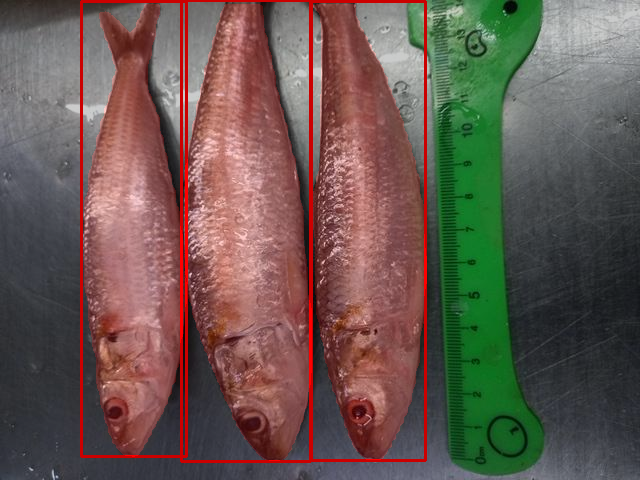

{'fishes-detected': 3,
 'good-fishes': 0,
 'bad-fishes': 3,
 'reasons': ['Size', 'Softness', 'Size'],
 'image-encode': '...',
 'classification': 'True',
 'species': 'sardine',
 'first3': ['Bad', 'Bad', 'Bad']}

In [18]:
image = '/content/drive/MyDrive/Sowmya /New app testing data/input/2024-07-30/sardine/Good/2024-07-30_09:57:45_(13907)_sardine_input.jpeg'
r, out = final_prediction(image, 'sardine', 'fish')
cv2_imshow(out)
r

Starting freshness prediction for species: sardine using model: fish.


Image successfully opened and converted to numpy array.


0: 480x640 3 fishs, 2905.5ms
Speed: 8.8ms preprocess, 2905.5ms inference, 15.0ms postprocess per image at shape (1, 3, 480, 640)



Fish/Prawn detection completed.
Starting freshness prediction for sardine.
Pre-processing image for damage detection model.
Image resized to 145x640.
Image padded and resized to 640x640.
Running Damage detection model.


0: 640x640 (no detections), 349.8ms
Speed: 8.1ms preprocess, 349.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


...

0: 640x640 (no detections), 311.1ms
Speed: 8.0ms preprocess, 311.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


No Damage Detected.
triggered!!!!!!!!


,Filename,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Scale,Fish,Circumference,Area
0,d062f649-7f22-41cc-adf4-43ae33ecbd3c.jpeg,12,3,12,13,1,0.027426,True,True,28,28


********lr probability : 0.8877252998688071 **********
size->Bad
Sardine has small size.
Prediction for fish 3: 3-Bad-Size
Applying masks and labels to the predicted image.
Masks and labels applied to the output image.
Final prediction results: Fishes detected:3 for species sardine, Good fishes:0 and Bad fishes: 3, Reasons: ['Size', 'Softness', 'Size']


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


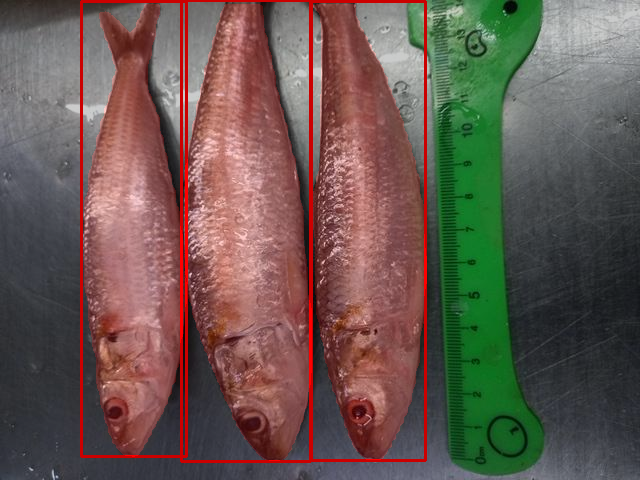

{'fishes-detected': 3,
 'good-fishes': 0,
 'bad-fishes': 3,
 'reasons': ['Size', 'Softness', 'Size'],
 'image-encode': '...',
 'classification': 'True',
 'species': 'sardine',
 'first3': ['Bad', 'Bad', 'Bad']}

In [11]:
img_path = '/content/drive/MyDrive/Sowmya /New app testing data/input/2024-07-30/sardine/Good/2024-07-30_09:57:45_(13907)_sardine_input.jpeg'
image = img_path
r, out = final_prediction(image, 'sardine', 'fish')
cv2_imshow(out)
r